# Bisecting K-Means - H&M (extended)


Evaluación del número de clusters y ajuste final del modelo. El `k` recomendado se selecciona mediante el mayor coeficiente silhouette.


In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from modeling_functions import (
    bisecting_kmeans_metrics,
    plot_clustering_metrics,
    analyze_clusters,
    fit_clustering_model,
    save_clustering_metrics,
)
import pandas as pd

## Carga y preparación de los datos


In [2]:
df_scaled = pd.read_csv("../../../scaled_data/hym_scaled.csv")
df_original = pd.read_csv("../../../extended_datasets/hym_model_extended.csv")

# Conserva en el escalado solo las variables incluidas en esta versión del dataset.
columnas_modelo = [col for col in df_original.columns if col in df_scaled.columns]
df_scaled_modelo = df_scaled[columnas_modelo].copy()
X = df_scaled_modelo.drop(columns=["customer_id"], errors="ignore")

print(f"Observaciones: {X.shape[0]:,}")
print(f"Variables de clustering: {X.shape[1]}")
display(X.head())

Observaciones: 1,362,281
Variables de clustering: 16


,recency,frequency,monetary,avg_basket_size,std_basket_size,avg_price,std_price,avg_days_between_purchases,std_days_between_purchases,unique_articles,unique_product_types,unique_product_groups,unique_sections,unique_garment_groups,article_variety_ratio,channel_2_ratio
0,-1.216313,0.926194,0.765377,-0.523798,0.210045,0.432196,0.617279,0.720704,0.918735,0.564508,0.998377,0.182468,0.679223,0.914649,-0.000656,-0.225281
1,-0.614156,1.811026,1.771317,0.374886,1.273567,0.375024,0.745891,0.329096,0.667697,1.585622,1.666834,1.502382,1.692838,1.596049,-1.120686,0.689212
2,-1.404203,0.565013,0.847795,-0.224068,0.869573,1.056084,0.735802,0.989724,1.301171,0.315278,0.699291,0.182468,0.822147,0.761901,-0.886381,0.832742
3,1.106440,-1.007279,-1.056769,-0.593223,-1.065388,0.396012,-1.679728,-1.316863,-1.029689,-1.079040,-1.414917,-1.137446,-1.361096,-1.418672,0.663637,0.832742
4,-0.918963,0.413566,0.433500,-0.478748,0.128600,0.848051,0.269839,1.038340,1.171898,0.191304,0.581088,0.622439,0.519447,0.397551,0.127092,0.452939


## Evaluación del número de clusters


In [3]:
resultados_bisecting = bisecting_kmeans_metrics(X)
display(resultados_bisecting)

,k,silhouette,calinski_harabasz,davies_bouldin,inertia,tiempo_segundos
0,2,0.366945,1.032232e+06,1.103214,1.240041e+07,3.511992
1,3,0.252434,6.459594e+05,1.767559,1.118715e+07,3.228193
2,4,0.186118,5.724838e+05,1.801392,9.641402e+06,4.086639
3,5,0.193163,4.887675e+05,1.811867,8.950791e+06,4.521797
4,6,0.182511,4.244668e+05,1.897423,8.521145e+06,5.449401
5,7,0.188082,3.848556e+05,1.785266,8.087587e+06,5.768797
6,8,0.162170,3.524044e+05,1.848958,7.754507e+06,6.474456
7,9,0.159397,3.211167e+05,1.909036,7.553101e+06,6.841153
8,10,0.159914,3.021589e+05,1.876158,7.274607e+06,7.032843


In [4]:
tabla_metricas = save_clustering_metrics(
    resultados_bisecting,
    model_name="bisecting",
    dataset_name="hym",
    dataset_version="extended",
)

print("Métricas consolidadas en ../../../results/clustering_metrics.csv")
display(tabla_metricas)

Métricas consolidadas en ../../../results/clustering_metrics.csv


,model,dataset,dataset_version,k,silhouette,calinski_harabasz,davies_bouldin,inertia,tiempo_segundos,n_clusters_found,fpc,objective_function,iterations,bic,aic
0,birch,hym,extended,2,0.340654,930935.773165,1.105585,NaN,56.925452,2.0,NaN,NaN,NaN,NaN,NaN
1,birch,hym,extended,3,0.230760,688890.908136,1.436553,NaN,55.993544,3.0,NaN,NaN,NaN,NaN,NaN
2,birch,hym,extended,4,0.203823,524871.689920,1.792945,NaN,55.849959,4.0,NaN,NaN,NaN,NaN,NaN
3,birch,hym,extended,5,0.191449,438249.783633,1.834154,NaN,56.909790,5.0,NaN,NaN,NaN,NaN,NaN
4,birch,hym,extended,6,0.148712,376866.681427,2.094143,NaN,56.928501,6.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,minibatch,instacart,simple,6,0.287861,92542.785246,1.110500,191238.961903,0.476716,NaN,NaN,NaN,NaN,NaN,NaN
248,minibatch,instacart,simple,7,0.287363,88688.845444,1.083745,173472.413504,0.090507,NaN,NaN,NaN,NaN,NaN,NaN
249,minibatch,instacart,simple,8,0.284887,90539.561492,1.089686,152061.334109,0.358054,NaN,NaN,NaN,NaN,NaN,NaN
250,minibatch,instacart,simple,9,0.282639,87440.639855,1.070433,140993.880428,0.330287,NaN,NaN,NaN,NaN,NaN,NaN


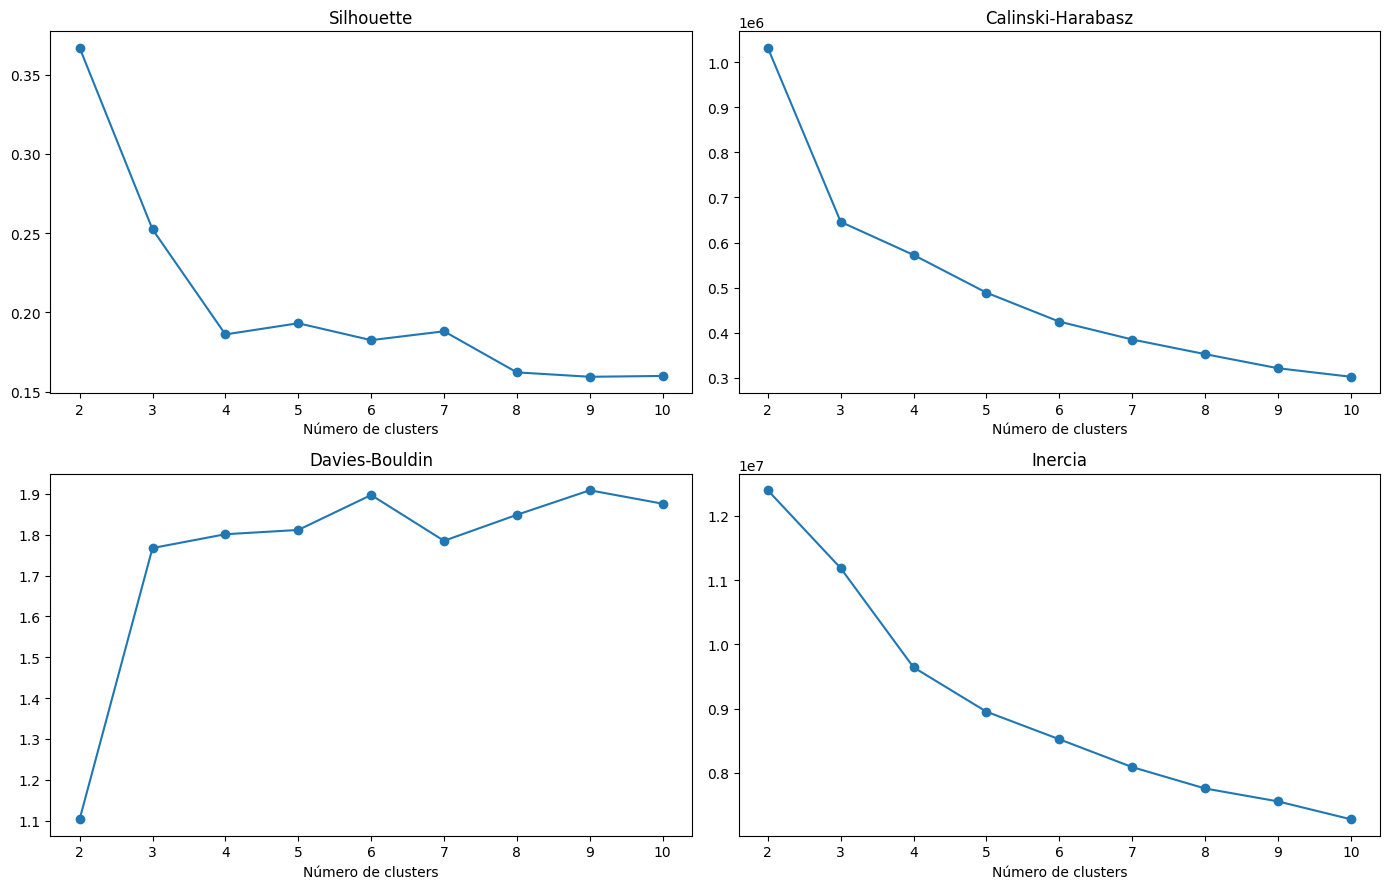

In [5]:
plot_clustering_metrics(
    resultados_bisecting,
    fourth_metric="inertia",
    fourth_title="Inercia",
)

## Ajuste final y perfil de los clusters


In [6]:
modelo, labels = fit_clustering_model(
    model_name="bisecting",
    k=2,
    X=X,
)

cluster_sizes, porcentajes, perfil_clusters, df_clusterizado = analyze_clusters(
    labels=labels,
    df_scaled=df_scaled_modelo,
    df_original=df_original,
    id_col="customer_id",
)

print("Tamaño de los clusters:")
display(cluster_sizes)
print("Porcentaje de clientes:")
display(porcentajes)
print("Perfil medio de los clusters:")
display(perfil_clusters)

Tamaño de los clusters:


cluster
0    704114
1    658167
Name: count, dtype: int64

Porcentaje de clientes:


cluster
0    51.69
1    48.31
Name: proportion, dtype: float64

Perfil medio de los clusters:


,recency,frequency,monetary,avg_basket_size,std_basket_size,avg_price,std_price,avg_days_between_purchases,std_days_between_purchases,unique_articles,unique_product_types,unique_product_groups,unique_sections,unique_garment_groups,article_variety_ratio,channel_2_ratio
cluster,,,,,,,,,,,,,,,,
0,119.641,11.533,1.152,3.915,2.608,0.028,0.016,80.141,68.109,35.415,12.479,5.252,9.888,8.977,0.888,0.628
1,360.790,1.458,0.111,3.066,0.341,0.030,0.008,39.758,6.866,3.601,2.427,1.802,2.137,2.162,0.923,0.700


- Cluster 0 - Clientes inactivos y de muy bajo valor (47,70%): presentan la mayor recencia, una frecuencia cercana a una sola compra y un gasto mínimo. Su actividad se concentra en pocos artículos y categorías y muestra escasa diversidad absoluta.
- Cluster 1 - Clientes activos, diversos y de alto valor (52,30%): compran más recientemente y con mucha mayor frecuencia y gasto. Sus cestas son mayores y recorren una variedad muy amplia de artículos, tipos, secciones y grupos, reflejando una relación estable con la marca.